## Final Project Submission

Please fill out:
* Students names: Clement Saini, David Munyaga, Nelius Githatu, Sam Binyanya, Shalom Cheptoo, John Paul
* Student pace: Full time 
* Scheduled project review date/time: 21st August 2026
* Instructor name: Sam G Mwangi
* Blog post URL:


# Movie Industry Analysis

## Overview

This project analyzes data from the movie industry to identify patterns and insights that can help inform business decisions. The analysis combines movie-related datasets to investigate factors such as movie performance, ratings, budgets, and revenues.

The goal is to use data analysis and visualization to answer relevant business questions and communicate actionable findings to stakeholders.

In [2]:
import pandas as pd

In [3]:
import os

os.listdir("zippedData")      #inspecting the dataset i.e whats inside that the ZippedData

['bom.movie_gross.csv.gz',
 'im.db.zip',
 'rt.movie_info.tsv.gz',
 'rt.reviews.tsv.gz',
 'tmdb.movies.csv.gz',
 'tn.movie_budgets.csv.gz']

### inspecting bom dataset

In [4]:
bom_df = pd.read_csv("zippedData/bom.movie_gross.csv.gz")

bom_df.head()                #inspecting the first dataset inside the zipped data

,title,studio,domestic_gross,foreign_gross,year
0,Toy Story 3,BV,415000000.0,652000000,2010
1,Alice in Wonderland (2010),BV,334200000.0,691300000,2010
2,Harry Potter and the Deathly Hallows Part 1,WB,296000000.0,664300000,2010
3,Inception,WB,292600000.0,535700000,2010
4,Shrek Forever After,P/DW,238700000.0,513900000,2010


In [5]:
#Inspect the structure of this dataset
bom_df.info()                     #df.info() Check structure and missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3387 entries, 0 to 3386
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           3387 non-null   object 
 1   studio          3382 non-null   object 
 2   domestic_gross  3359 non-null   float64
 3   foreign_gross   2037 non-null   object 
 4   year            3387 non-null   int64  
dtypes: float64(1), int64(1), object(3)
memory usage: 132.4+ KB


In [6]:
bom_df.describe()      # describe () - gives you a quick statistical summary of the DataFrame

,domestic_gross,year
count,3.359000e+03,3387.000000
mean,2.874585e+07,2013.958075
std,6.698250e+07,2.478141
min,1.000000e+02,2010.000000
25%,1.200000e+05,2012.000000
50%,1.400000e+06,2014.000000
75%,2.790000e+07,2016.000000
max,9.367000e+08,2018.000000


In [7]:
bom_df.isna().sum()   #.isna().sum() is used in Pandas to count missing values in each column

title                0
studio               5
domestic_gross      28
foreign_gross     1350
year                 0
dtype: int64

In [8]:
bom_df.duplicated().sum()     #.duplicated().sum() is used in Pandas to count duplicate rows in a DataFrame

np.int64(0)

### inspecting foreign gross column inside the bom

In [9]:
bom_df["foreign_gross"].head(10)        #head(10) to show the first 10 rows

0    652000000
1    691300000
2    664300000
3    535700000
4    513900000
5    398000000
6    311500000
7    391000000
8    291600000
9    277300000
Name: foreign_gross, dtype: object

In [10]:
bom_df["foreign_gross"].map(type).value_counts()   #.map(type).value_counts() to find out what Python data types are in a Pandas column and count how many values belong to each type.

foreign_gross
<class 'str'>      2037
<class 'float'>    1350
Name: count, dtype: int64

- the initial data types showed foreign_gross as object while domestic_gross as float so foreign_gross was not consistently numeric
- We change foreign_gross from object to float because we wante Pandas to treat the values as numbers, not text

In [11]:
bom_df["foreign_gross"] = pd.to_numeric(bom_df["foreign_gross"], errors="coerce")

In [12]:
bom_df["foreign_gross"].dtype

dtype('float64')

In [13]:
bom_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3387 entries, 0 to 3386
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           3387 non-null   object 
 1   studio          3382 non-null   object 
 2   domestic_gross  3359 non-null   float64
 3   foreign_gross   2032 non-null   float64
 4   year            3387 non-null   int64  
dtypes: float64(2), int64(1), object(2)
memory usage: 132.4+ KB


- find rows where foreign_gross is missing, but the movie title is present, and then show the first 20 of those rows.

In [14]:
bom_df[bom_df["foreign_gross"].isna() & bom_df["title"].notna()].head(20)


,title,studio,domestic_gross,foreign_gross,year
222,Flipped,WB,1800000.0,NaN,2010
254,The Polar Express (IMAX re-issue 2010),WB,673000.0,NaN,2010
267,Tiny Furniture,IFC,392000.0,NaN,2010
269,Grease (Sing-a-Long re-issue),Par.,366000.0,NaN,2010
280,Last Train Home,Zeit.,288000.0,NaN,2010
287,Sweetgrass,CGld,207000.0,NaN,2010
291,Casino Jack and the United States of Money,Magn.,177000.0,NaN,2010
308,Alamar,FM,61600.0,NaN,2010
311,Hatchet 2,Vita.,52600.0,NaN,2010
319,Living in Emergency,Truly,32200.0,NaN,2010


## inspecting imdb dataset

In [15]:
import zipfile     #imports Python's zipfile module, which gives Python the ability to work with .zip files.

with zipfile.ZipFile("zippedData/im.db.zip", "r") as zip_ref:   #Open the ZIP file and gives a temporary name zip_ref
    print(zip_ref.namelist())            #namelist() gets a list of the names of all files inside the ZIP file.

['im.db']


In [16]:
with zipfile.ZipFile("zippedData/im.db.zip", "r") as zip_ref:  #r is the read mode i.e let me read what is inside the dataset
    zip_ref.extractall("zippedData")             #take everything inside the ZIP file and extract it into the zippedData folder

In [17]:
os.listdir("zippedData")   #what files are inside the zippedData folder

['bom.movie_gross.csv.gz',
 'im.db',
 'im.db.zip',
 'rt.movie_info.tsv.gz',
 'rt.reviews.tsv.gz',
 'tmdb.movies.csv.gz',
 'tn.movie_budgets.csv.gz']

In [18]:
import sqlite3       #loads Python's SQLite module since we want to work with SQLite dataset

conn = sqlite3.connect("zippedData/im.db")  #we connect Python to the actual SQLite database that we just extracted

In [19]:
pd.read_sql("""     
SELECT name
FROM sqlite_master
WHERE type = 'table';
""", conn)                       #what tables are there inside SQLite dataset

,name
0,movie_basics
1,directors
2,known_for
3,movie_akas
4,movie_ratings
5,persons
6,principals
7,writers


In [20]:
pd.read_sql("SELECT * FROM movie_basics LIMIT 5;", conn)   #first 5 rows of the movie_basics table in SQLite database.

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres
0,tt0063540,Sunghursh,Sunghursh,2013,175.0,"Action,Crime,Drama"
1,tt0066787,One Day Before the Rainy Season,Ashad Ka Ek Din,2019,114.0,"Biography,Drama"
2,tt0069049,The Other Side of the Wind,The Other Side of the Wind,2018,122.0,Drama
3,tt0069204,Sabse Bada Sukh,Sabse Bada Sukh,2018,NaN,"Comedy,Drama"
4,tt0100275,The Wandering Soap Opera,La Telenovela Errante,2017,80.0,"Comedy,Drama,Fantasy"


In [21]:
pd.read_sql("PRAGMA table_info(movie_basics);", conn)       #structure of the movie_basics table - datatypes and columns

,cid,name,type,notnull,dflt_value,pk
0,0,movie_id,TEXT,0,None,0
1,1,primary_title,TEXT,0,None,0
2,2,original_title,TEXT,0,None,0
3,3,start_year,INTEGER,0,None,0
4,4,runtime_minutes,REAL,0,None,0
5,5,genres,TEXT,0,None,0


In [22]:
pd.read_sql("SELECT * FROM movie_ratings LIMIT 5;", conn)     #first 5 rows of the movie_ratings table in SQLite database

,movie_id,averagerating,numvotes
0,tt10356526,8.3,31
1,tt10384606,8.9,559
2,tt1042974,6.4,20
3,tt1043726,4.2,50352
4,tt1060240,6.5,21


In [23]:
pd.read_sql("PRAGMA table_info(movie_ratings);", conn)      #structure of the movie_ratings table - datatypes and columns

,cid,name,type,notnull,dflt_value,pk
0,0,movie_id,TEXT,0,None,0
1,1,averagerating,REAL,0,None,0
2,2,numvotes,INTEGER,0,None,0


In [24]:
pd.read_sql("""
SELECT
    (SELECT COUNT(*) FROM movie_basics) AS movie_basics_count,
    (SELECT COUNT(*) FROM movie_ratings) AS movie_ratings_count;
""", conn)     #count how many rows are in movie_basics and how many rows are in movie_ratings

,movie_basics_count,movie_ratings_count
0,146144,73856


- we now join the movie_basics and movie_ratings table using INNER JOIN because we only want movies that have information in both tables.

In [25]:
imdb_df = pd.read_sql("""
SELECT
    mb.movie_id,
    mb.primary_title,
    mb.start_year,
    mb.runtime_minutes,
    mb.genres,
    mr.averagerating,
    mr.numvotes
FROM movie_basics AS mb
INNER JOIN movie_ratings AS mr
    ON mb.movie_id = mr.movie_id         
""", conn)

imdb_df.head()        #combining the movie_basics and movie_ratings tables into one Pandas DataFrame called imdb_df

,movie_id,primary_title,start_year,runtime_minutes,genres,averagerating,numvotes
0,tt0063540,Sunghursh,2013,175.0,"Action,Crime,Drama",7.0,77
1,tt0066787,One Day Before the Rainy Season,2019,114.0,"Biography,Drama",7.2,43
2,tt0069049,The Other Side of the Wind,2018,122.0,Drama,6.9,4517
3,tt0069204,Sabse Bada Sukh,2018,NaN,"Comedy,Drama",6.1,13
4,tt0100275,The Wandering Soap Opera,2017,80.0,"Comedy,Drama,Fantasy",6.5,119


In [26]:
imdb_df.shape    #size of your DataFrame (number of rows, number of columns)

(73856, 7)

In [27]:
bom_df.info()  #inspect bom  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3387 entries, 0 to 3386
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           3387 non-null   object 
 1   studio          3382 non-null   object 
 2   domestic_gross  3359 non-null   float64
 3   foreign_gross   2032 non-null   float64
 4   year            3387 non-null   int64  
dtypes: float64(2), int64(1), object(2)
memory usage: 132.4+ KB


In [28]:
imdb_df.info()  #inspect imdb 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73856 entries, 0 to 73855
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   movie_id         73856 non-null  object 
 1   primary_title    73856 non-null  object 
 2   start_year       73856 non-null  int64  
 3   runtime_minutes  66236 non-null  float64
 4   genres           73052 non-null  object 
 5   averagerating    73856 non-null  float64
 6   numvotes         73856 non-null  int64  
dtypes: float64(2), int64(2), object(3)
memory usage: 3.9+ MB


- we notice title in bom and primary title in idmb. we also notice year in bom and start year in idmb
- we there start with those columns to check if they contain the same values
- bom at the left and idmb at the right

In [29]:
merged_df = pd.merge(
    imdb_df,
    bom_df,
    left_on=["primary_title", "start_year"],
    right_on=["title", "year"],
    how="inner"
)

merged_df.head()     #combine the imdb_df DataFrame with the bom_df DataFrame using the movie's title and year
                     #imdb_df contains information from IMDb
                     #bom_df contains information from Box Office Mojo:

,movie_id,primary_title,start_year,runtime_minutes,genres,averagerating,numvotes,title,studio,domestic_gross,foreign_gross,year
0,tt0315642,Wazir,2016,103.0,"Action,Crime,Drama",7.1,15378,Wazir,Relbig.,1100000.0,NaN,2016
1,tt0337692,On the Road,2012,124.0,"Adventure,Drama,Romance",6.1,37886,On the Road,IFC,744000.0,8000000.0,2012
2,tt0359950,The Secret Life of Walter Mitty,2013,114.0,"Adventure,Comedy,Drama",7.3,275300,The Secret Life of Walter Mitty,Fox,58200000.0,129900000.0,2013
3,tt0365907,A Walk Among the Tombstones,2014,114.0,"Action,Crime,Drama",6.5,105116,A Walk Among the Tombstones,Uni.,26300000.0,26900000.0,2014
4,tt0369610,Jurassic World,2015,124.0,"Action,Adventure,Sci-Fi",7.0,539338,Jurassic World,Uni.,652300000.0,NaN,2015


In [30]:
merged_df.shape

(1847, 12)

In [31]:
merged_df.isna().sum()

movie_id             0
primary_title        0
start_year           0
runtime_minutes      4
genres               2
averagerating        0
numvotes             0
title                0
studio               2
domestic_gross      10
foreign_gross      582
year                 0
dtype: int64

## Genre Analysis

### 1. average domestic gross

- clean and restructur the genres column so that each genre gets its own row instead of having several genres packed into one cell

In [32]:
genre_df = merged_df.dropna(subset=["genres"]).copy()  #Remove any rows where the genres column is NaN.
        #Why .copy()? dropna() creates a new DataFrame. .copy() makes an explicit independent copy so we can safely modify genre_df without accidentally modifying merged_df.

genre_df["genres"] = genre_df["genres"].str.split(",")  #Whenever you see a comma, split the text there

genre_df = genre_df.explode("genres")  #appear once for each genre

genre_df["genres"] = genre_df["genres"].str.strip()   #.str.strip() removes those unnecessary spaces

genre_df.head()    #Show the first 5 rows

,movie_id,primary_title,start_year,runtime_minutes,genres,averagerating,numvotes,title,studio,domestic_gross,foreign_gross,year
0,tt0315642,Wazir,2016,103.0,Action,7.1,15378,Wazir,Relbig.,1100000.0,NaN,2016
0,tt0315642,Wazir,2016,103.0,Crime,7.1,15378,Wazir,Relbig.,1100000.0,NaN,2016
0,tt0315642,Wazir,2016,103.0,Drama,7.1,15378,Wazir,Relbig.,1100000.0,NaN,2016
1,tt0337692,On the Road,2012,124.0,Adventure,6.1,37886,On the Road,IFC,744000.0,8000000.0,2012
1,tt0337692,On the Road,2012,124.0,Drama,6.1,37886,On the Road,IFC,744000.0,8000000.0,2012


In [33]:
genre_performance = (
    genre_df.groupby("genres")["domestic_gross"]
    .mean()
    .sort_values(ascending=False)
)

genre_performance      #calculates the average domestic box-office gross for each movie genre, then sorts the genres from highest average to lowest.

genres
Sci-Fi         1.327263e+08
Animation      1.164578e+08
Adventure      1.120633e+08
Action         6.965484e+07
Fantasy        6.723078e+07
Family         6.067217e+07
Western        4.601374e+07
Comedy         4.548149e+07
Thriller       4.008991e+07
Horror         3.572114e+07
Mystery        3.362882e+07
Musical        3.199856e+07
Crime          3.059485e+07
Sport          2.855126e+07
Biography      2.761252e+07
History        2.630811e+07
Music          2.531965e+07
Drama          2.331968e+07
Romance        1.979957e+07
War            9.504526e+06
Documentary    4.889789e+06
News           1.320000e+04
Name: domestic_gross, dtype: float64

### 2. number of movies

In [34]:
genre_counts = genre_df["genres"].value_counts()

genre_counts                    #counting how many times each genre appears in the genre_df

genres
Drama          960
Comedy         655
Action         523
Adventure      363
Romance        299
Thriller       288
Crime          269
Biography      189
Horror         148
Mystery        130
Fantasy        124
Animation      113
Sci-Fi         109
Documentary    101
Family          82
History         72
Music           60
Sport           35
War             23
Musical         12
Western         11
News             1
Name: count, dtype: int64

### 3. median domestic gross

In [35]:
genre_summary = (
    genre_df.groupby("genres")
    .agg(
        median_domestic_gross=("domestic_gross", "median"),
        average_domestic_gross=("domestic_gross", "mean"),
        movie_count=("title", "count")
    )
    .sort_values("median_domestic_gross", ascending=False)
)

genre_summary       #summary table for each movie genre 

,median_domestic_gross,average_domestic_gross,movie_count
genres,,,
Animation,85900000.0,1.164578e+08,113
Sci-Fi,79200000.0,1.327263e+08,109
Adventure,64700000.0,1.120633e+08,363
Family,43900000.0,6.067217e+07,82
Fantasy,31100000.0,6.723078e+07,124
Action,25100000.0,6.965484e+07,523
Horror,21700000.0,3.572114e+07,148
Comedy,17800000.0,4.548149e+07,655
Mystery,15900000.0,3.362882e+07,130


# Visualization 1 : Genre vs Domestic gross

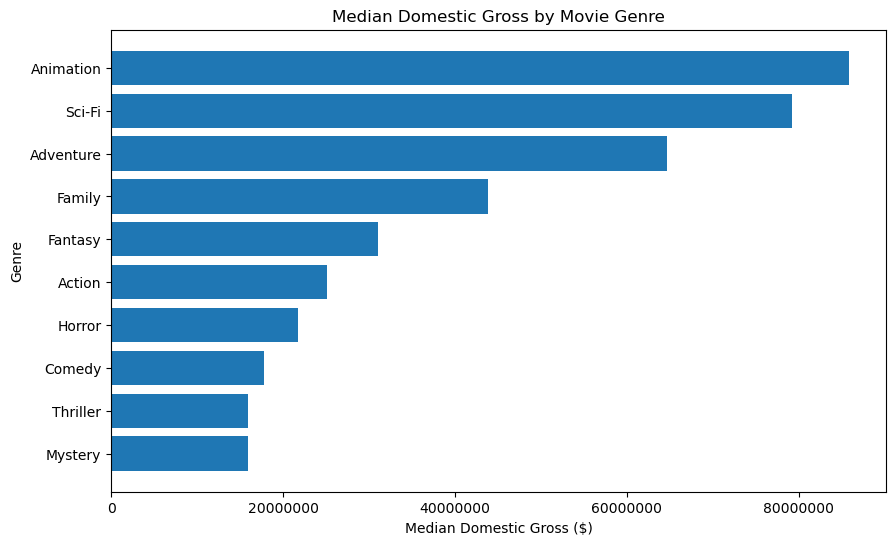

In [36]:
import matplotlib.pyplot as plt  #imports Matplotlib's plotting tool so we can create graphs and charts in Python

top_genres = genre_summary.head(10).sort_values("median_domestic_gross")  #top 10 movie genres based on median domestic gross

plt.figure(figsize=(10, 6))
plt.barh(top_genres.index, top_genres["median_domestic_gross"])

plt.title("Median Domestic Gross by Movie Genre")
plt.xlabel("Median Domestic Gross ($)")
plt.ylabel("Genre")
plt.ticklabel_format(style="plain", axis="x")

plt.show()   

## Finding : Some Genres Have Stronger Domestic gross Performance
Animation had the highest median domestic gross $85.9M followed by Sci-Fi then adventure
- what does this tell us

  The animation, Sci-fi and adventure movies performed much better domestically than the lower genre from that dataset

## Business recommendation for Visualization 1 (Genre vs Domestic gross)

The new studio should prioritize Animation, Sci-Fi, and Adventure projects because they show substantially stronger typical domestic box-office performance than most other genres

# Visualization 2 : Genre vs IMDB rating

In [37]:

# Calculate median IMDb rating by genre
rating_stats = (
    merged_df.groupby("genres")["averagerating"]
    .agg(["median", "mean", "count"])
    .sort_values("median", ascending=False)
)

rating_stats        #calculate movie ratings stats by genre

,median,mean,count
genres,,,
"Adventure,Drama,Sci-Fi",8.3,8.3,2
"Documentary,Sport",8.2,8.2,1
"Biography,Documentary,Thriller",8.1,8.1,1
"Documentary,History,War",8.0,8.0,2
"Comedy,Crime,Documentary",8.0,8.0,1
...,...,...,...
"Animation,Drama",4.5,4.5,1
"Action,Family,Fantasy",4.3,4.3,1
"Animation,Family",4.0,4.0,1


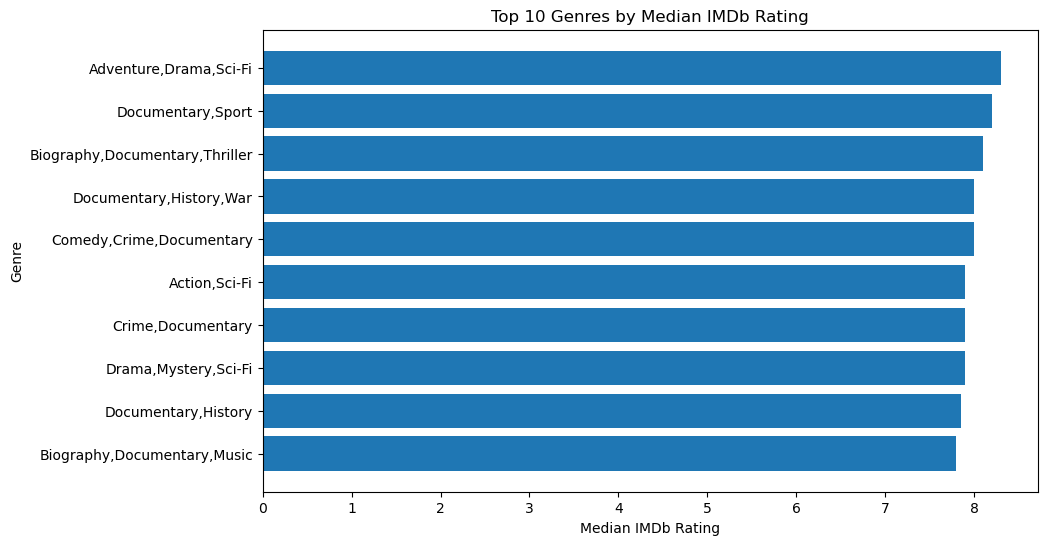

In [38]:
# Top 10 genres by median IMDb rating
rating_plot = rating_stats.head(10)

plt.figure(figsize=(10, 6))
plt.barh(rating_plot.index[::-1], rating_plot["median"][::-1])
plt.xlabel("Median IMDb Rating")
plt.ylabel("Genre")
plt.title("Top 10 Genres by Median IMDb Rating")
plt.show()

### Finding : High IMDb Ratings Do Not Automatically Mean High Revenue
After comparing IMDb ratings with domestic gross  we found out that

# Visualization 3 : Year vs Domestic gross

In [39]:
# Median domestic gross by year
year_stats = (
    merged_df.groupby("year")["domestic_gross"]
    .median()
    .sort_index()
)

year_stats      

year
2010    21450000.0
2011    15400000.0
2012    11600000.0
2013    15300000.0
2014     9450000.0
2015     4700000.0
2016     6200000.0
2017     7200000.0
2018    12000000.0
Name: domestic_gross, dtype: float64

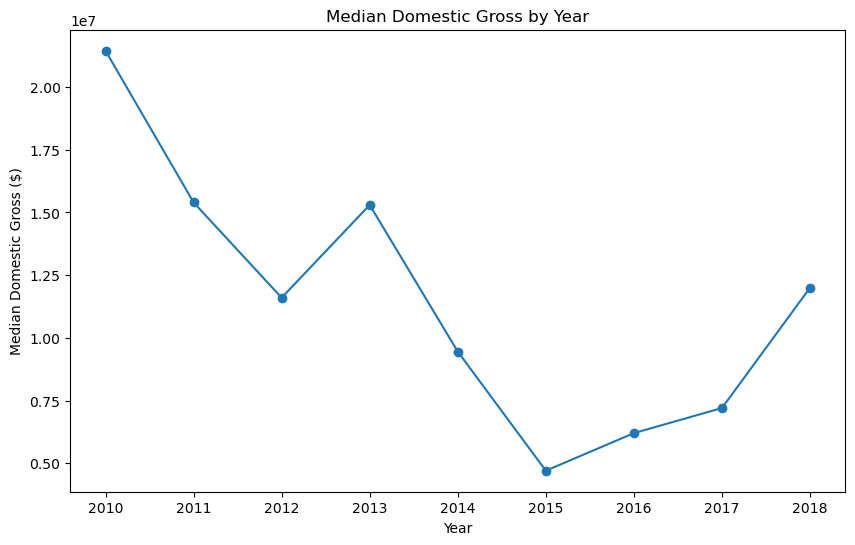

In [40]:
plt.figure(figsize=(10, 6))
plt.plot(year_stats.index, year_stats.values, marker="o")
plt.xlabel("Year")
plt.ylabel("Median Domestic Gross ($)")
plt.title("Median Domestic Gross by Year")
plt.xticks(year_stats.index)
plt.show()

## Findings : 
median domestic gross was high in 2010 then dropped upto 2012 before rising again slightly from 2012 to 2013, dropped again to 2015 and then began recovering again through 2018

## Recommendation for visualization 3 on Year vs Domestic gross
Condider market timing and changing market condition; the studio should use a cautious, data-driven investment strategy, starting with commercially promising genres rather than committing large budgets across many genres. The company should therefore continue monitoring market performance as it develops its movie portfolio.

# Visualization 4 : IMDB Rating vs Domestic gross

In [41]:
genre_ratings = (
    genre_df.groupby("genres")
    .agg(
        median_rating=("averagerating", "median"),
        average_rating=("averagerating", "mean"),
        movie_count=("title", "count")
    )
    .sort_values("median_rating", ascending=False)
)

genre_ratings

,median_rating,average_rating,movie_count
genres,,,
Documentary,7.40,7.329703,101
Sport,7.20,7.034286,35
Biography,7.00,7.023810,189
War,6.90,6.595652,23
History,6.90,6.883333,72
Music,6.75,6.708333,60
News,6.70,6.700000,1
Animation,6.70,6.568142,113
Drama,6.70,6.590000,960


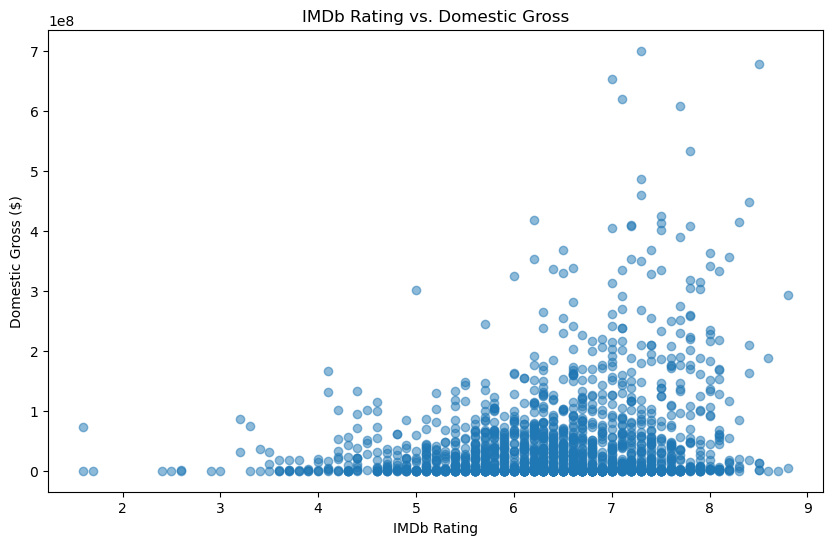

In [42]:
#Do better rated movies actually make more money


plt.figure(figsize=(10, 6))

plt.scatter(
    merged_df["averagerating"],
    merged_df["domestic_gross"],
    alpha=0.5
)

plt.xlabel("IMDb Rating")
plt.ylabel("Domestic Gross ($)")
plt.title("IMDb Rating vs. Domestic Gross")
plt.show()

## Finding :  High IMDb Ratings Do Not Automatically Mean High Revenue
The highest IMDb rating was for Documentary with rating 7.4, but its domestic mean was only $527,500

Animation had a lower median rating of 6.7, but its median domestic gross was $85.9M

## Business Recommendation for visualization 4
Do not rely on IMDb ratings alone when deciding which movies to invest in. Instead, combine audience ratings with commercially successful genres and other market factors when selecting projects because a high rating does not necessarily translate into high box-office revenue

# Visualization 5 : Top studios by Median domestic gross

In [43]:
#The median is preferable here because a studio may have one or two blockbuster movies that could make its average look unusually high
# Calculate median domestic gross and movie count by studio
studio_stats = (
    merged_df.dropna(subset=["studio", "domestic_gross"])
    .groupby("studio")
    .agg(
        median_domestic_gross=("domestic_gross", "median"),
        movie_count=("title", "count")
    )
)

# Keep studios with at least 10 movies for a more reliable comparison
studio_stats = studio_stats[studio_stats["movie_count"] >= 10]

# Select the top 10 studios
top_studios = studio_stats.sort_values(
    "median_domestic_gross",
    ascending=False
).head(10)

top_studios

,median_domestic_gross,movie_count
studio,,
P/DW,157250000.0,10
BV,96950000.0,84
Sony,69300000.0,80
Par.,68000000.0,78
WB (NL),65200000.0,41
Fox,64099999.0,113
Uni.,62900000.0,124
WB,57000000.0,102
SGem,39400000.0,27


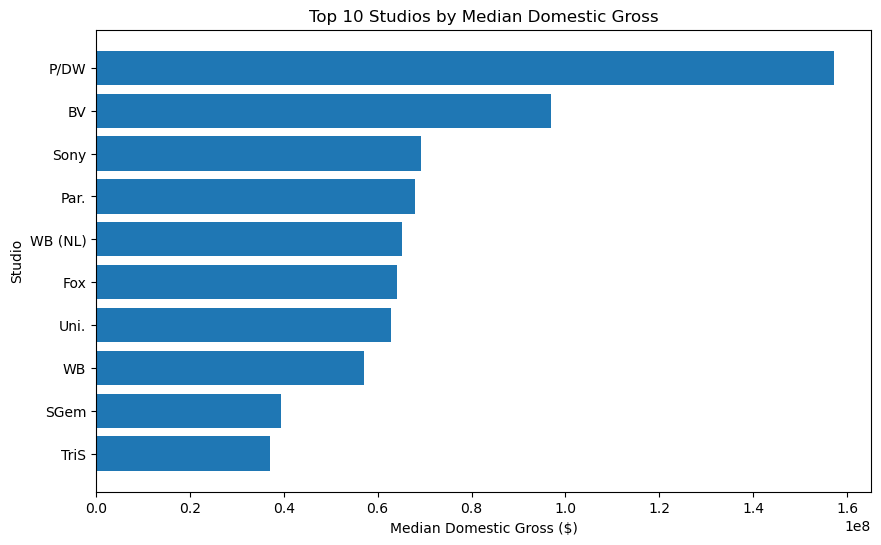

In [44]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_studios.index[::-1],
    top_studios["median_domestic_gross"][::-1]
)

plt.xlabel("Median Domestic Gross ($)")
plt.ylabel("Studio")
plt.title("Top 10 Studios by Median Domestic Gross")

plt.show()

## Findings :
Our studio comparison showed that domestic box-office performance differed across studios, with P/DW and BV among the stronger performers in the selected comparison.

What it tells us

Success is not determined only by the movie itself.

The studio's:

distribution,
marketing,
release strategy,
audience reach,

can also influence performance.

## Business recommendation from Visualization 5

Prioritize partnerships and distribution strategies with studios that demonstrate stronger domestic box-office performance by studying the practices, distribution reach, and audience strategies of the highest-performing studios

# Visualization 6 : Number of movies by Genre

In [45]:
# Which genre are most common in the market

genre_counts = genre_df["genres"].value_counts()

genre_counts.head(10)

genres
Drama        960
Comedy       655
Action       523
Adventure    363
Romance      299
Thriller     288
Crime        269
Biography    189
Horror       148
Mystery      130
Name: count, dtype: int64

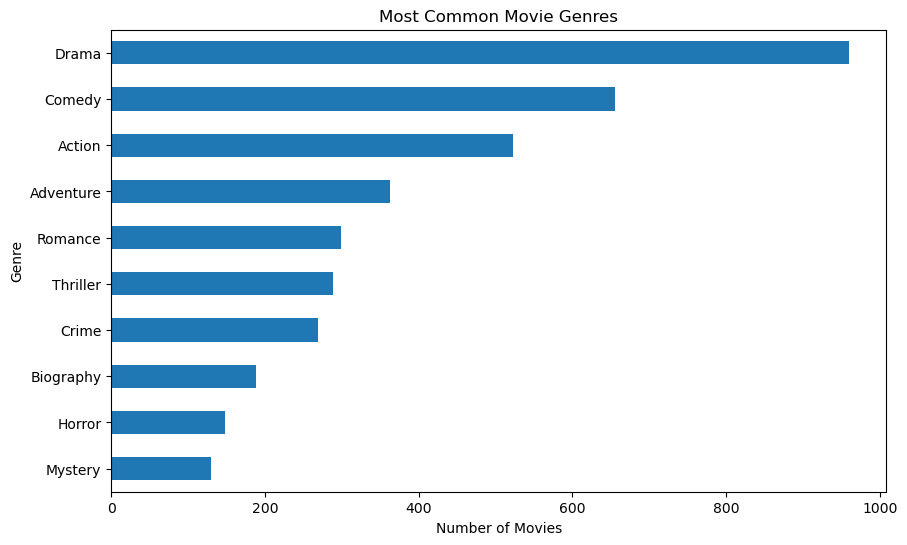

In [46]:
plt.figure(figsize=(10, 6))

genre_counts.head(10).sort_values().plot(kind="barh")

plt.xlabel("Number of Movies")
plt.ylabel("Genre")
plt.title("Most Common Movie Genres")

plt.show()

### Finding 
The Market Is Concentrated in a Few Genres
- Drama has by far the most movies about 960
- Comedy follows with about 655
- Action has about 523
- Adventure has about 363
- Romance, Thriller, and Crime have roughly 269–299 movies
- Biography, Horror, and Mystery have considerably fewer
So Drama, Comedy, and Action are therefore among the most represented genres in our dataset

## Business recommendation from Visualization 6

Avoid relying solely on the most represented genres and explore opportunities in less crowded genres with strong revenue potential;The studio should recognize that Drama, Comedy, and Action have many competing titles

# Visualization 7 : Number of votes vs Domestic gross

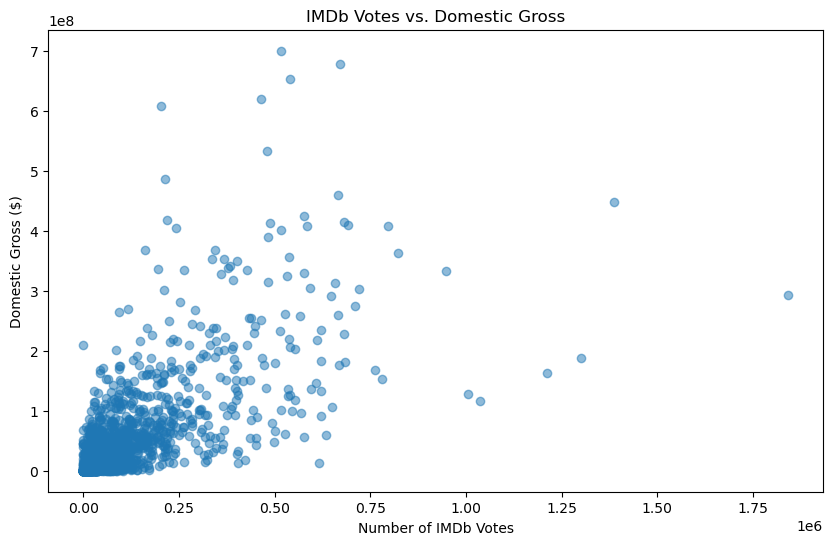

In [47]:
#Do movies that attract more audience attention also earn more?

plt.figure(figsize=(10, 6))

plt.scatter(
    merged_df["numvotes"],
    merged_df["domestic_gross"],
    alpha=0.5
)

plt.xlabel("Number of IMDb Votes")
plt.ylabel("Domestic Gross ($)")
plt.title("IMDb Votes vs. Domestic Gross")

plt.show()

# Visualization 8 : Runtime vs Domestic gross

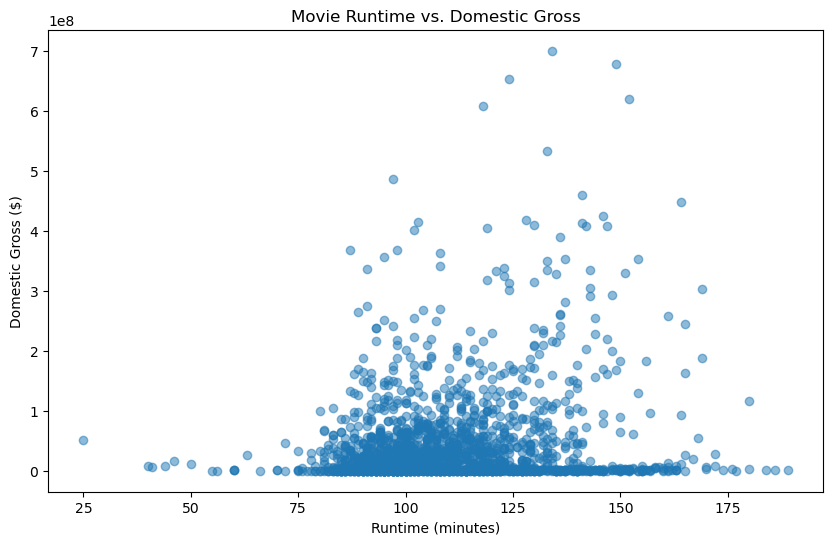

In [48]:
# This answers the question;Does movie length appear to be associated with box - office performance?

runtime_data = merged_df.dropna(
    subset=["runtime_minutes", "domestic_gross"]
)

plt.figure(figsize=(10, 6))

plt.scatter(
    runtime_data["runtime_minutes"],
    runtime_data["domestic_gross"],
    alpha=0.5
)

plt.xlabel("Runtime (minutes)")
plt.ylabel("Domestic Gross ($)")
plt.title("Movie Runtime vs. Domestic Gross")

plt.show()

# Visualization 9 : Average rating by year

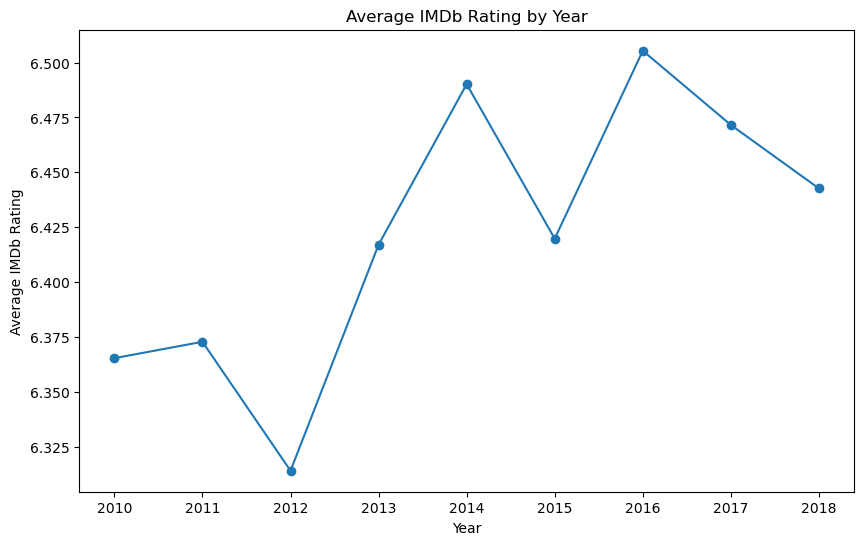

In [49]:
# This helps us see whether rating has changed over time


rating_by_year = (
    merged_df.groupby("year")["averagerating"]
    .mean()
)

plt.figure(figsize=(10, 6))

plt.plot(
    rating_by_year.index,
    rating_by_year.values,
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Average IMDb Rating")
plt.title("Average IMDb Rating by Year")
plt.xticks(rating_by_year.index)

plt.show()

# visualization 10 : Top studios

In [50]:
#visualization 10 : Top studios
# We keep the studio analysis we started


studio_stats = (
    merged_df.dropna(subset=["studio", "domestic_gross"])
    .groupby("studio")
    .agg(
        median_domestic_gross=("domestic_gross", "median"),
        movie_count=("title", "count")
    )
)

studio_stats = studio_stats[studio_stats["movie_count"] >= 10]

top_studios = studio_stats.sort_values(
    "median_domestic_gross",
    ascending=False
).head(10)

top_studios

,median_domestic_gross,movie_count
studio,,
P/DW,157250000.0,10
BV,96950000.0,84
Sony,69300000.0,80
Par.,68000000.0,78
WB (NL),65200000.0,41
Fox,64099999.0,113
Uni.,62900000.0,124
WB,57000000.0,102
SGem,39400000.0,27


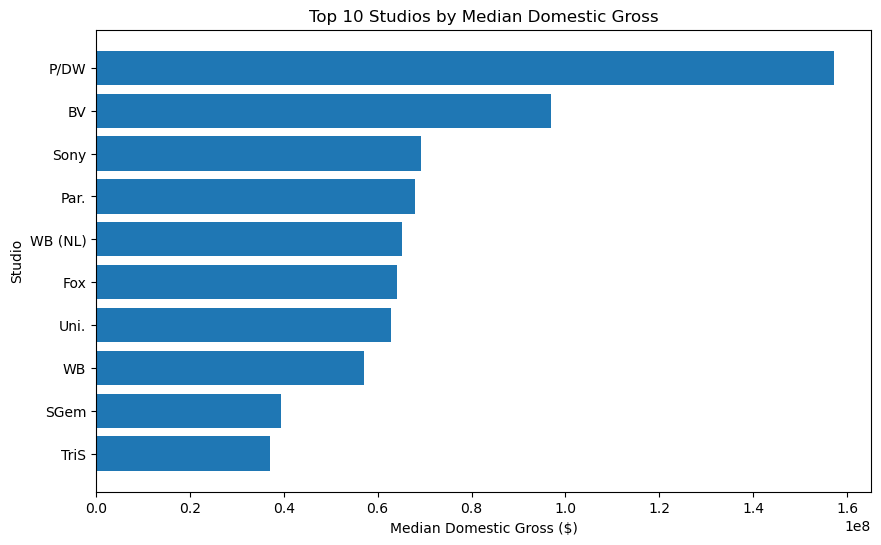

In [51]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_studios.index[::-1],
    top_studios["median_domestic_gross"][::-1]
)

plt.xlabel("Median Domestic Gross ($)")
plt.ylabel("Studio")
plt.title("Top 10 Studios by Median Domestic Gross")

plt.show()

### IMDb Ratings, Votes, and Worldwide Gross

This analysis investigates the relationships between IMDb ratings, the number of IMDb votes, and worldwide box-office gross. Correlation analysis was used to measure the strength and direction of these relationships, while scatter plots were used to visually examine the relationships between IMDb votes, IMDb ratings, and worldwide gross.

The analysis found that the number of IMDb votes has a moderate positive relationship with worldwide gross, while IMDb rating has a weaker positive relationship with worldwide gross.

In [60]:
merged_df[[
    "averagerating",
    "numvotes",
    "domestic_gross",
    "foreign_gross"
]].head()

,averagerating,numvotes,domestic_gross,foreign_gross
0,7.1,15378,1100000.0,NaN
1,6.1,37886,744000.0,8000000.0
2,7.3,275300,58200000.0,129900000.0
3,6.5,105116,26300000.0,26900000.0
4,7.0,539338,652300000.0,NaN


In [61]:
correlation = merged_df[
    ['averagerating', 'numvotes', 'domestic_gross', 'foreign_gross']
].corr()

correlation

,averagerating,numvotes,domestic_gross,foreign_gross
averagerating,1.000000,0.376188,0.215396,0.220082
numvotes,0.376188,1.000000,0.699409,0.580483
domestic_gross,0.215396,0.699409,1.000000,0.823449
foreign_gross,0.220082,0.580483,0.823449,1.000000


### Correlation Analysis

The correlation results show that domestic gross and foreign gross have the strongest positive relationship, with a correlation of 0.823. This suggests that movies that perform well domestically also tend to perform well internationally.

The number of IMDb votes has a moderately strong positive relationship with domestic gross (0.699) and a moderate positive relationship with foreign gross (0.580). This indicates that movies with more IMDb votes generally tend to generate higher box-office earnings.

IMDb rating has weaker relationships with box-office earnings, with correlations of 0.215 with domestic gross and 0.220 with foreign gross. This suggests that a higher IMDb rating alone is not strongly associated with higher box-office earnings.

There is also a weak-to-moderate positive correlation between IMDb rating and number of votes (0.376), indicating that higher-rated movies tend to receive somewhat more votes.

### Relationship Between IMDb Votes and Domestic Gross

Examine the relationship between the number of IMDb votes and domestic box-office gross using a scatter plot.


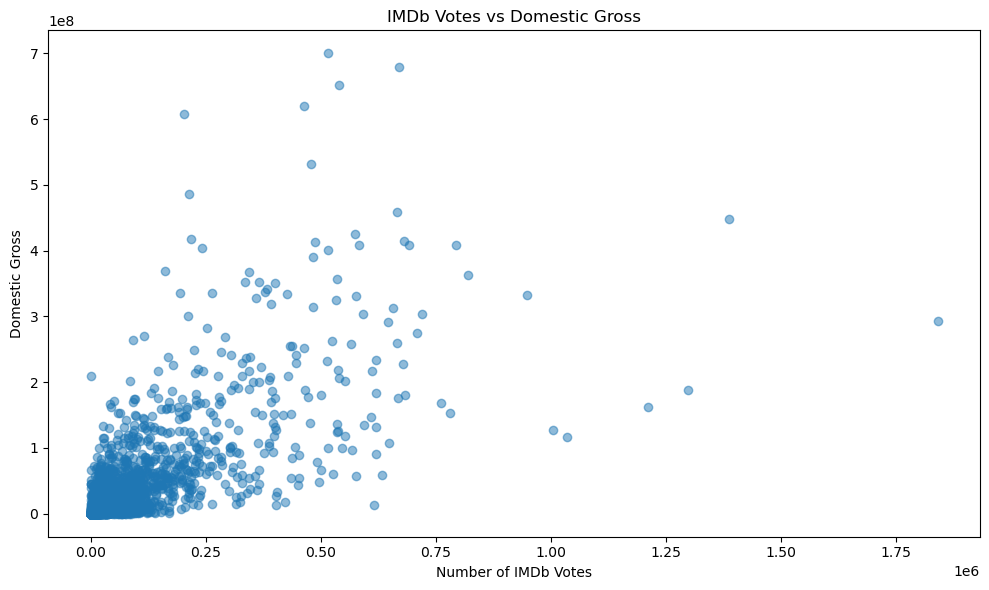

In [62]:
plt.figure(figsize=(10, 6))

plt.scatter(merged_df['numvotes'], merged_df['domestic_gross'], alpha=0.5)

plt.title('IMDb Votes vs Domestic Gross')
plt.xlabel('Number of IMDb Votes')
plt.ylabel('Domestic Gross')

plt.tight_layout()
plt.show()

### Relationship Between IMDb Votes and Foreign Gross

Examine the relationship between the number of IMDb votes and foreign box-office gross using a scatter plot.

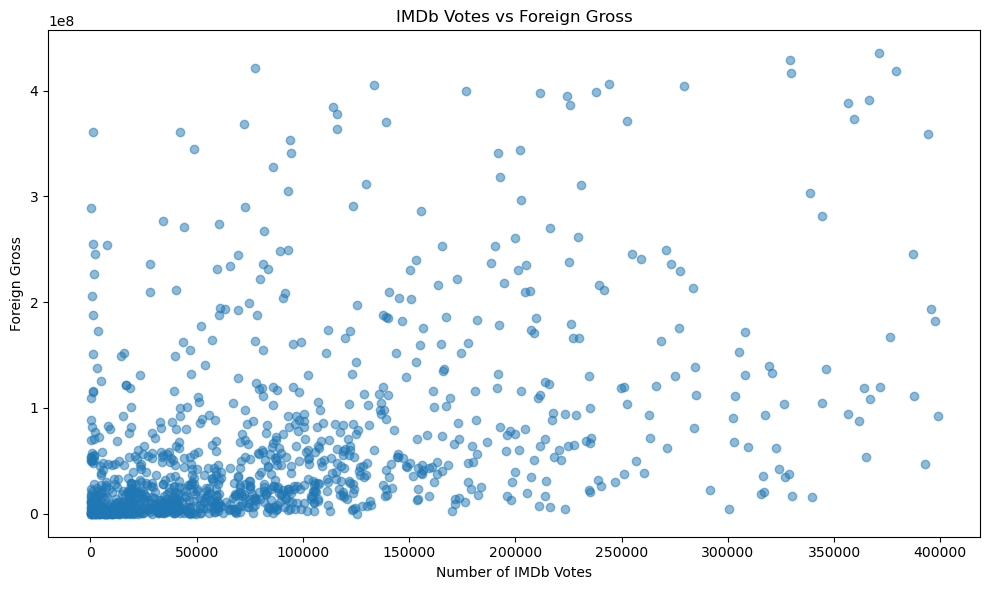

In [63]:
plt.figure(figsize=(10, 6))

plot_data = merged_df[
    (merged_df['numvotes'] <= merged_df['numvotes'].quantile(0.95)) &
    (merged_df['foreign_gross'] <= merged_df['foreign_gross'].quantile(0.95))
]

plt.scatter(
    plot_data['numvotes'],
    plot_data['foreign_gross'],
    alpha=0.5
)

plt.title('IMDb Votes vs Foreign Gross')
plt.xlabel('Number of IMDb Votes')
plt.ylabel('Foreign Gross')

plt.tight_layout()
plt.show()

### Interpretation

The scatter plots show a positive relationship between the number of IMDb votes and box-office earnings. Movies with more IMDb votes generally tend to have higher domestic and foreign gross earnings.

The relationship appears stronger for domestic gross than for foreign gross, which is consistent with the correlation results. The correlation between IMDb votes and domestic gross is 0.699, compared with 0.580 for IMDb votes and foreign gross.

This suggests that the number of IMDb votes is more strongly associated with domestic box-office performance than foreign box-office performance.

### Calculate Worldwide Gross

Create a new column for worldwide gross by combining domestic and foreign box-office earnings.

In [64]:
merged_df['worldwide_gross'] = (
    merged_df['domestic_gross'] + merged_df['foreign_gross']
)

merged_df[['domestic_gross', 'foreign_gross', 'worldwide_gross']].head()

,domestic_gross,foreign_gross,worldwide_gross
0,1100000.0,NaN,NaN
1,744000.0,8000000.0,8744000.0
2,58200000.0,129900000.0,188100000.0
3,26300000.0,26900000.0,53200000.0
4,652300000.0,NaN,NaN


### Correlation Between IMDb Metrics and Worldwide Gross

Remove movies with missing worldwide gross values and calculate the correlations between IMDb rating, number of votes, and worldwide gross.

In [65]:
worldwide_df = merged_df.dropna(
    subset=['averagerating', 'numvotes', 'worldwide_gross']
)

worldwide_correlation = worldwide_df[
    ['averagerating', 'numvotes', 'worldwide_gross']
].corr()

worldwide_correlation

,averagerating,numvotes,worldwide_gross
averagerating,1.000000,0.462015,0.242869
numvotes,0.462015,1.000000,0.633506
worldwide_gross,0.242869,0.633506,1.000000


### Interpretation of Correlations

The correlation analysis shows a moderate positive relationship between the number of IMDb votes and worldwide gross, with a correlation coefficient of 0.634. This suggests that movies with more IMDb votes generally tend to have higher worldwide box-office earnings.

IMDb rating has a weak positive relationship with worldwide gross, with a correlation coefficient of 0.243. This indicates that higher-rated movies do not necessarily generate substantially higher worldwide earnings.

There is also a moderate positive relationship between IMDb rating and number of votes, with a correlation coefficient of 0.462. This suggests that higher-rated movies tend to receive more IMDb votes.

### Relationship Between IMDb Votes and Worldwide Gross

Examine the relationship between the number of IMDb votes and worldwide gross using a scatter plot.

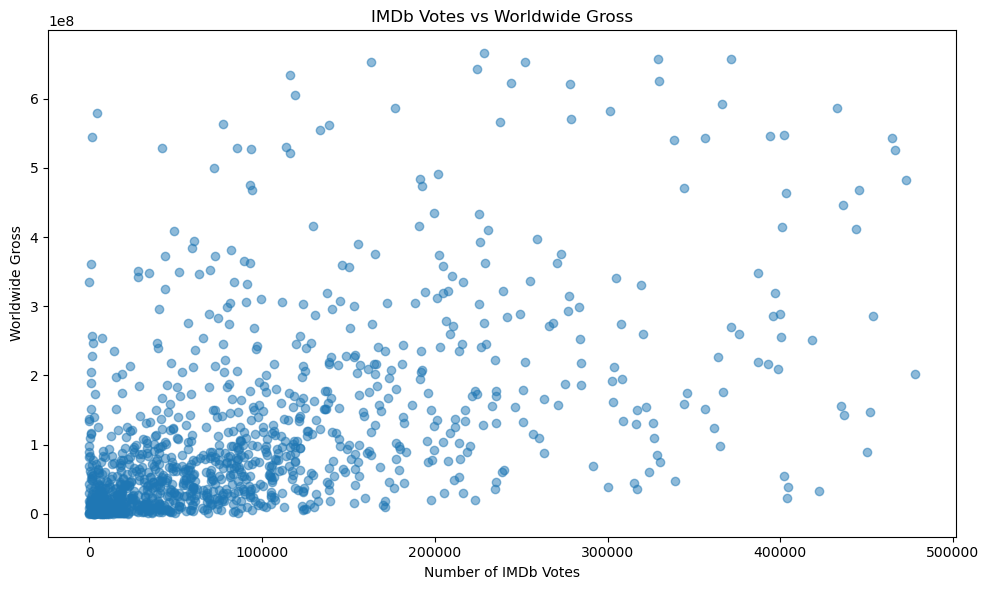

In [66]:
plt.figure(figsize=(10, 6))

plot_data = worldwide_df[
    (worldwide_df['numvotes'] <= worldwide_df['numvotes'].quantile(0.95)) &
    (worldwide_df['worldwide_gross'] <= worldwide_df['worldwide_gross'].quantile(0.95))
]

plt.scatter(
    plot_data['numvotes'],
    plot_data['worldwide_gross'],
    alpha=0.5
)

plt.title('IMDb Votes vs Worldwide Gross')
plt.xlabel('Number of IMDb Votes')
plt.ylabel('Worldwide Gross')

plt.tight_layout()
plt.show()

### Relationship Between IMDb Rating and Worldwide Gross

Examine the relationship between IMDb rating and worldwide gross using a scatter plot.

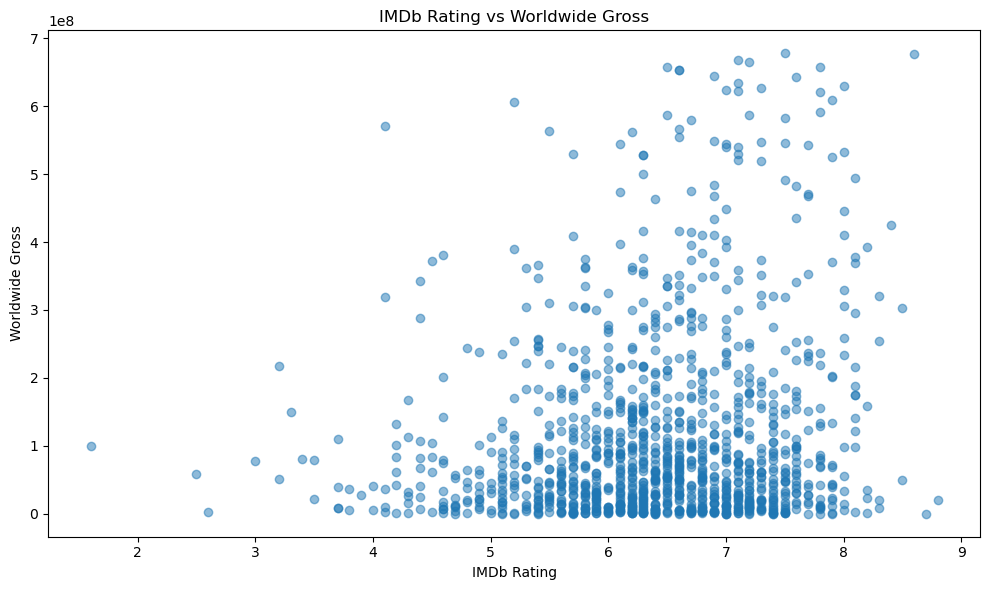

In [67]:
plt.figure(figsize=(10, 6))

plot_data = worldwide_df[
    worldwide_df['worldwide_gross'] <= worldwide_df['worldwide_gross'].quantile(0.95)
]

plt.scatter(
    plot_data['averagerating'],
    plot_data['worldwide_gross'],
    alpha=0.5
)

plt.title('IMDb Rating vs Worldwide Gross')
plt.xlabel('IMDb Rating')
plt.ylabel('Worldwide Gross')

plt.tight_layout()
plt.show()

### Overall Findings

The analysis shows that the number of IMDb votes has a moderate positive relationship with worldwide gross (r = 0.634), indicating that movies with more votes generally tend to earn more worldwide.

In contrast, IMDb rating has only a weak positive relationship with worldwide gross (r = 0.243). This suggests that a movie having a higher IMDb rating does not necessarily mean it will generate higher worldwide earnings.

Overall, the number of IMDb votes appears to be more strongly associated with worldwide box-office performance than IMDb rating.

# Overview of what we have done 

# Project Goal

The main goal of this project is to **help a new movie studio make data-driven business decisions about entering the movie industry**.

Specifically, our analysis aims to:

* Identify **movie genres with strong domestic box-office performance**.
* Examine whether **IMDb ratings are associated with domestic box-office success**.
* Compare **domestic box-office performance across studios**.
* Identify **less-saturated genres** that may provide opportunities for the new studio.
* Use these findings to develop **practical business recommendations** for the studio.

> **We are trying to determine what types of movies the new studio should consider producing and what strategies could increase its chances of commercial success.**

---

# Methods

## 1. Data Collection and Exploration

We worked with data from **IMDb** and **Box Office Mojo**.

The IMDb database contained several tables, including:

* `movie_basics`
* `movie_ratings`
* `directors`
* `writers`
* `persons`
* `principals`

For our analysis, we primarily used **`movie_basics`** and **`movie_ratings`**.

We also used Box Office Mojo data to examine domestic and foreign box-office performance and studio information.

---

## 2. Data Cleaning

We inspected the datasets for:

* Data types
* Missing values
* Number of observations
* Dataset structure

Some columns required cleaning before analysis. For example, `foreign_gross` was initially stored as an `object` because it contained both strings and numerical values. We converted it to a numeric data type so that it could be used for numerical analysis.

We also identified missing values in several columns.

---

## 3. Data Merging

We combined IMDb information with Box Office Mojo information to create a single dataset for analysis.

The resulting `merged_df` contained **1,847 movies and 12 columns**, including:

* Movie ID
* Movie title
* Year
* Runtime
* Genre
* IMDb rating
* Number of votes
* Studio
* Domestic gross
* Foreign gross

---

## 4. Genre Transformation

Because movies can belong to multiple genres, we separated genre combinations into individual genres.

For example:

`Action,Crime,Drama`

was separated into:

* Action
* Crime
* Drama

This allowed us to compare the performance of individual genres more effectively.

---

## 5. Descriptive Statistics

We calculated several descriptive statistics, including:

* Mean domestic gross
* Median domestic gross
* Movie counts
* Mean IMDb rating
* Median IMDb rating
* Studio-level statistics
* Yearly statistics

We particularly relied on **median domestic gross** when comparing genres because movie revenues contain very large blockbuster values that can distort the mean.

---

## 6. Visual Analysis

We created visualizations to examine:

1. Genre vs. domestic gross
2. Genre vs. IMDb rating
3. Year vs. domestic gross
4. IMDb rating vs. domestic gross
5. Studio vs. domestic gross
6. Number of movies by genre
- Investigated the relationship between IMDb ratings, number of votes, and worldwide gross.
- Calculated correlation coefficients to measure the strength and direction of these relationships.
- Created scatter plots to visualize the relationships between IMDb votes and worldwide gross, and IMDb ratings and worldwide gross.

These visualizations helped us identify patterns that could be useful for business decision-making.

---

# Results and Findings

Results and findings are clearly illustrated

---

# Overall Story

The movie market is highly competitive and concentrated in genres such as **Drama, Comedy, and Action**. However, our analysis indicates that some less-saturated genres, particularly **Animation, Sci-Fi, Adventure, and Family**, have stronger typical domestic box-office performance.

At the same time, **IMDb ratings alone do not guarantee financial success**, meaning that the studio should consider multiple factors when selecting projects. Finally, substantial differences in studio performance suggest that **distribution and release strategies may also influence commercial outcomes**.

Overall, the analysis suggests that the new studio should focus on **genres with strong box-office potential while avoiding unnecessary competition in highly saturated genres**.

---

# Business Recommendations

Based on our findings, we recommend that the new movie studio:

### 1. Prioritize High-Performing Genres

Consider developing projects in **Animation, Sci-Fi, Adventure, and Family**, which demonstrated strong median domestic box-office performance in our dataset.

### 2. Avoid Relying on IMDb Ratings Alone

Use IMDb ratings as one indicator of audience reception, but combine them with other factors such as **genre, market demand, budget, distribution strategy, and expected audience size** when evaluating potential projects.

### 3. Explore Less-Saturated Opportunities

Rather than competing heavily in highly represented genres such as Drama and Comedy, consider opportunities in **less-saturated genres with strong box-office performance**, particularly Animation and Sci-Fi.

### 4. Learn From Successful Studios

Study the strategies of stronger-performing studios, particularly their **distribution and release strategies**, and adapt relevant practices to the new studio's own business model.

### 5. Look for opportunities where performance and competition balance well

Don't simply choose the most popular genre; consider how crowded the market is.

### Conclusion

**The data suggests that the new studio should pursue high-performing but relatively less-saturated genres, use multiple factors rather than IMDb ratings alone when selecting projects, and learn from successful studios' distribution strategies. This approach can help the studio make more informed decisions and improve its chances of commercial success.**
